## ANN (Artificial Neural Network) for Classification

ANN are computer systems designed to mimic how the human brain processes information. Just like the brain uses neurons to process data and make decisions, ANNs use artificial neurons to analyze data, identify patterns and make predictions. These networks consist of layers of interconnected neurons that work together to solve complex problems. The key idea is that ANNs can "learn" from the data they process, just as our brain learns from experience.

---

### One vs all (OvA) Classification

This is the previous method we used for multi-class classification. In this method geven **noClasses* we had *noClasses* binary classifiers, each one trained to distinguish one class from the rest. For example, if we had 3 classes (A, B, C), we would train 3 classifiers: one to distinguish A from not A (B and C), one to distinguish B from not B (A and C), and one to distinguish C from not C (A and B). During prediction, we would run all classifiers and choose the class with the highest confidence score.

_This approach is fairly reasonable when the total number of classes is small, but becomes increasingly inefficient as the number of classes rises_

### ANN for Multi-class Classification

In contrast to the OvA approach, ANNs can handle multi-class classification directly. Instead of training separate binary classifiers, we can design a single ANN that outputs a probability distribution over all classes. The output layer of the ANN will have as many neurons as there are classes, and each neuron will represent the probability of the input belonging to that class.

To calculate the probability we will use softmax function.
$$ P(y=k|x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}} $$

---

### Iris Dataset Example
Last time we used OvA to classify the iris of a flower, now we will use the same dataset but with ANN. Nore exactly an **MLP** (multilayer perceptor).

A **MLP** is a foundational feedforward neural network comprising at least three layers (input, hidden, output) of fully connected nodes, or neurons. Used in supervised learning, it uses nonlinear activation functions (e.g., ReLU, Sigmoid) and backpropagation to learn, enabling it to classify non-linearly separable data and model complex functions.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('./data/iris.data', header=None, names=['sepal length', 'sepal width', 'petal length', 'petal width', 'class'])

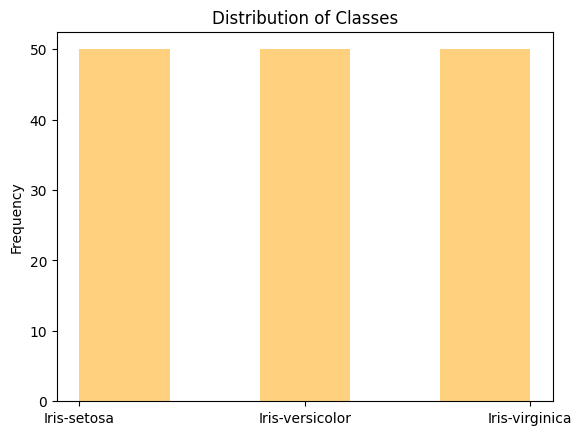

In [12]:
import matplotlib.pyplot as plt

# plot distribution of classes
hist = plt.hist(df['class'], bins=5, alpha=0.5, color='orange')	
plt.ylabel('Frequency')
plt.title('Distribution of Classes')
plt.show()

Here we can see that we have an equal amount of samples for each class, which is good for training our ANN.

Now let's see if our data must be normalized before training our ANN. We can do this by plotting the distribution of each feature.

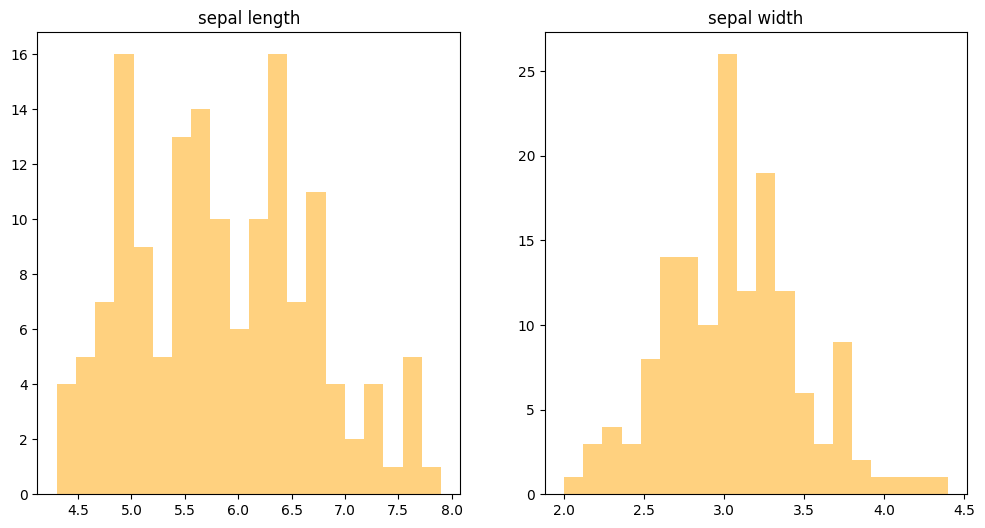

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i, feature in enumerate(df.columns[:-3]):
	axs[i].hist(df[feature], bins=20, alpha=0.5, color='orange')
	axs[i].set_title(feature)

In [33]:
def min_max_normalize(column):
	min_val = column.min()
	max_val = column.max()
	return (column - min_val) / (max_val - min_val)

normalized_df = df.copy()
for feature in df.columns[:-3]:
	normalized_df[feature] = min_max_normalize(df[feature])

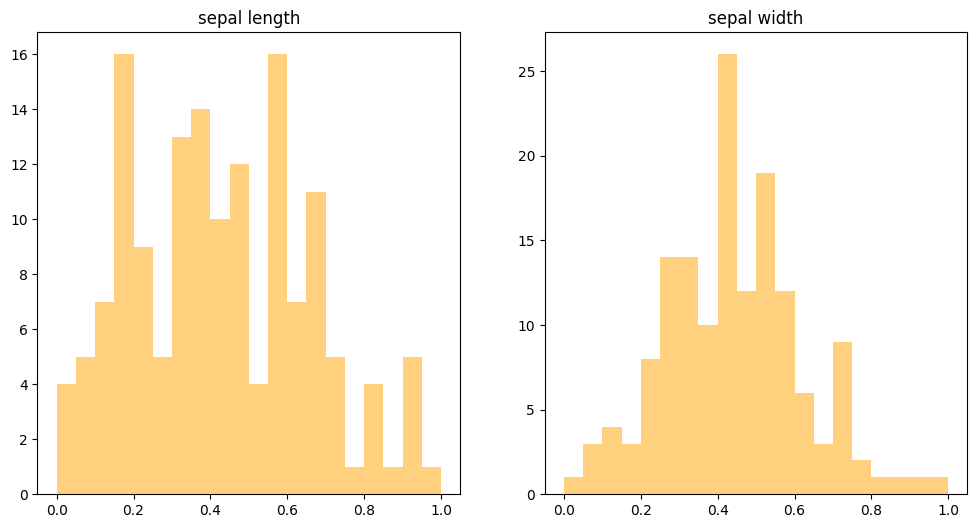

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i, feature in enumerate(normalized_df.columns[:-3]):
	axs[i].hist(normalized_df[feature], bins=20, alpha=0.5, color='orange')
	axs[i].set_title(feature)

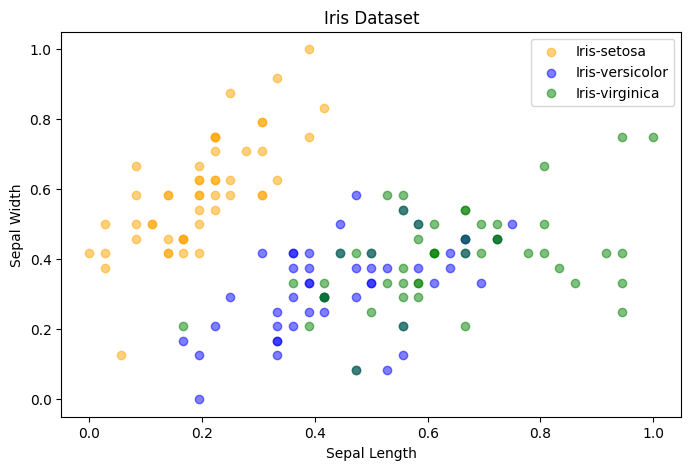

In [39]:
class_color_mapping = {
	'Iris-setosa': 'orange',
	'Iris-versicolor': 'blue',
	'Iris-virginica': 'green'
}

plt.figure(figsize=(8, 5))
for class_name in df['class'].unique():
	class_data = normalized_df[normalized_df['class'] == class_name]
	plt.scatter(class_data['sepal length'], class_data['sepal width'], color=class_color_mapping[class_name], label=class_name, alpha=0.5)

plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Iris Dataset')
plt.legend()
plt.show()

In [48]:
from sklearn import neural_network
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X = normalized_df[['sepal length', 'sepal width']]
y = normalized_df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = neural_network.MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
model.fit(X_train, y_train)

e:\GitHub\University_projects\semester 4\AI\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.88      0.78      0.82         9
 Iris-virginica       0.83      0.91      0.87        11

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



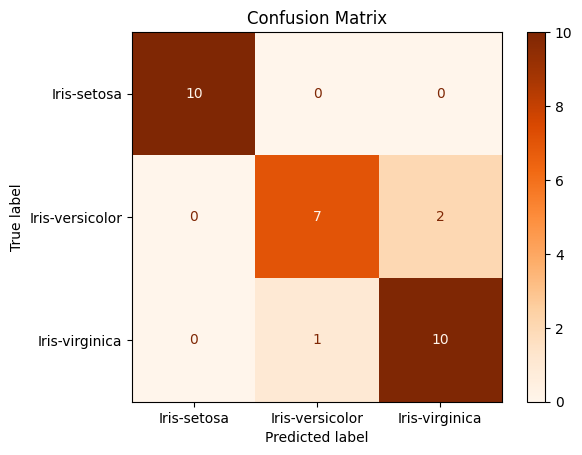

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_).plot(cmap='Oranges')
plt.title('Confusion Matrix')
plt.show()

<img src="./img/iris_output_linear_reggresion.png" alt="Feature Distribution" width="600">

In the imagine with blue we have the confusion mantrix of the logistic regression model, and in the imagine with orange we have the confusion matrix of the ANN model. 

We would expect the ANN to perform better than the logistic regression, but in this instance we can see that there is not that big of a difference between the two models. 

This is because the data is linearly separable for the first class, and where we see that bouth models performed worse is in the last two classes, we can see in the plot of the distribution of the features that it dosen't realy look like there is a clear separation between the last two classes, and this is why both models performed worse in those classes.
**ALSO THE LOGISTIC REGRESSION MODEL USES ALL _FOUR_ FEATURES!**

However, if we had a bigger or more complex dataset, we would expect the ANN to perform better than the logistic regression, because the ANN can learn more complex patterns in the data, while the logistic regression can only learn linear patterns.